# Data Cleaning and Preprocessing

## Importing Libraries

In [287]:
import warnings

warnings.filterwarnings('ignore')

In [288]:
import pandas as pd
import re
import nltk
import string
import numpy as np


## Download dataset from huggingface

In [289]:
from huggingface_hub import login
from datasets import load_dataset
import pandas as pd

"""# Huggingface_hub Login
login()"""

"""# Loading the dataset into a pandas dataframe
df = pd.DataFrame(load_dataset("Tobi-Bueck/customer-support-tickets")['train'])

# Saving the dataset
df.to_csv("datasets/Customer_Support_Tickets.csv")"""

df = load_dataset("Tobi-Bueck/customer-support-tickets")['train'].to_pandas()

## Data Lookup

In [290]:
# First 5 rows
df.head()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
0,Wesentlicher Sicherheitsvorfall,"Sehr geehrtes Support-Team,\n\nich möchte eine...",Vielen Dank für die Meldung des kritischen Sic...,Incident,Technical Support,high,de,51.0,Security,Outage,Disruption,Data Breach,NaN,NaN,NaN,NaN
1,Account Disruption,"Dear Customer Support Team,\n\nI am writing to...","Thank you for reaching out, <name>. We are awa...",Incident,Technical Support,high,en,51.0,Account,Disruption,Outage,IT,Tech Support,NaN,NaN,NaN
2,Query About Smart Home System Integration Feat...,"Dear Customer Support Team,\n\nI hope this mes...",Thank you for your inquiry. Our products suppo...,Request,Returns and Exchanges,medium,en,51.0,Product,Feature,Tech Support,NaN,NaN,NaN,NaN,NaN
3,Inquiry Regarding Invoice Details,"Dear Customer Support Team,\n\nI hope this mes...",We appreciate you reaching out with your billi...,Request,Billing and Payments,low,en,51.0,Billing,Payment,Account,Documentation,Feedback,NaN,NaN,NaN
4,Question About Marketing Agency Software Compa...,"Dear Support Team,\n\nI hope this message reac...",Thank you for your inquiry. Our product suppor...,Problem,Sales and Pre-Sales,medium,en,51.0,Product,Feature,Feedback,Tech Support,NaN,NaN,NaN,NaN


In [291]:
# Last 5 rows
df.tail()

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
61760,Assistance Needed for IFTTT Docker Integration,I am facing integration problems with IFTTT Do...,I would be happy to assist with the IFTTT Dock...,Problem,Technical Support,low,en,NaN,Integration,Disruption,Performance,IT,Tech Support,NaN,NaN,NaN
61761,Bitten um Unterstützung bei der Integration,"Sehr geehrte Kundenservice, ich möchte die Int...","Sehr geehrte [Name], vielen Dank für Ihren Kon...",Change,Technical Support,medium,de,NaN,Integration,Feature,Documentation,Tech Support,NaN,NaN,NaN,NaN
61762,NaN,"Hello Customer Support, I am inquiring about t...",We will send you detailed information on plans...,Request,Billing and Payments,low,en,NaN,Billing,Payment,Feature,Feedback,Sales,Lead,NaN,NaN
61763,Hilfe bei digitalen Strategie-Problemen,Die Qualität unserer digitalen Strategie-Bearb...,Um den digitalen Strategie-Impuls zu überprüfe...,Incident,Product Support,high,de,NaN,Feedback,Performance,IT,Tech Support,NaN,NaN,NaN,NaN
61764,Optimierung Ihrer Datenanalyse-Plattform erlei...,"Sehr geehrte Customer Support-Team, ich schrei...","Sehr geehrter <name>, wir antworten Ihnen auf ...",Change,Sales and Pre-Sales,medium,de,NaN,Product,Feature,Performance,Guidance,Documentation,NaN,NaN,NaN


In [292]:
df.describe(include='all')

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
count,56466,61763,48576,48587,61765,61765,61765,28587.000000,48587,48528,48356,43990,27636,13225,5968,2472
unique,46635,53364,40139,4,52,5,2,NaN,211,350,591,831,956,920,755,512
top,Synchronisationsproblem,Support needed,Currently investigating the issue,Incident,Technical Support,medium,de,NaN,Security,Performance,IT,Tech Support,Tech Support,Tech Support,Tech Support,Documentation
freq,3,2,2,19444,14186,23378,33504,NaN,9156,8698,9430,10004,6904,2606,512,166
mean,NaN,NaN,NaN,NaN,NaN,NaN,NaN,278.382027,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
std,NaN,NaN,NaN,NaN,NaN,NaN,NaN,165.962935,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
min,NaN,NaN,NaN,NaN,NaN,NaN,NaN,51.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
25%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,52.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
50%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
75%,NaN,NaN,NaN,NaN,NaN,NaN,NaN,400.000000,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [293]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 61765 entries, 0 to 61764
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   subject   56466 non-null  str    
 1   body      61763 non-null  str    
 2   answer    48576 non-null  str    
 3   type      48587 non-null  str    
 4   queue     61765 non-null  str    
 5   priority  61765 non-null  str    
 6   language  61765 non-null  str    
 7   version   28587 non-null  float64
 8   tag_1     48587 non-null  str    
 9   tag_2     48528 non-null  str    
 10  tag_3     48356 non-null  str    
 11  tag_4     43990 non-null  str    
 12  tag_5     27636 non-null  str    
 13  tag_6     13225 non-null  str    
 14  tag_7     5968 non-null   str    
 15  tag_8     2472 non-null   str    
dtypes: float64(1), str(15)
memory usage: 57.2 MB


## Data Cleaning

### Missing values

In [294]:
# Calculate the percentage of missing values in each row
def per_missing_values(df):
    return df.isna().mean() * 100

per_missing_values(df)

subject      8.579292
body         0.003238
answer      21.353517
type        21.335708
queue        0.000000
priority     0.000000
language     0.000000
version     53.716506
tag_1       21.335708
tag_2       21.431231
tag_3       21.709706
tag_4       28.778434
tag_5       55.256213
tag_6       78.588197
tag_7       90.337570
tag_8       95.997733
dtype: float64

### Removing rows with missing body

In [295]:
df = df[~df['body'].isna()]

In [296]:
df[df['subject'].isna()]

,subject,body,answer,type,queue,priority,language,version,tag_1,tag_2,tag_3,tag_4,tag_5,tag_6,tag_7,tag_8
870,NaN,"Customer Support, I am requesting comprehensiv...",Please provide detailed integration instructio...,Request,Technical Support,high,en,52.0,Support,Documentation,Troubleshooting,Integration,Configuration,Database,Guidance,Best Practices
887,NaN,"Customer Support,\n\nI am reporting a critical...","<name>, I regret to hear about the security br...",Incident,Technical Support,high,en,52.0,Security,Outage,Disruption,Recovery,IT,Tech Support,NaN,NaN
888,NaN,Die Leistung der digitalen Kampagnen unserer M...,Überprüfen Sie die Kampagnenberichte und verei...,Incident,Customer Service,medium,de,52.0,Performance,Outage,Disruption,Recovery,Security,NaN,NaN,NaN
915,NaN,"Customer Support, drafting a request for enhan...","<name>, thank you for your email regarding the...",Change,Customer Service,medium,en,52.0,Feature,Performance,Feedback,Data Analytics,Investment,Decision Making,NaN,NaN
929,NaN,Customer support has received a report regardi...,We have received a report about a security inc...,Incident,Billing and Payments,high,en,52.0,Security,Malware,Outage,Disruption,Recovery,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61719,NaN,Looking for assistance in securing medical dat...,Can provide guidance on securing medical data ...,Request,Customer Service,medium,en,NaN,Security,Documentation,IT,Tech Support,NaN,NaN,NaN,NaN
61726,NaN,Ein kritischer Fehler ist während der Projektm...,Wir haben eine kritische Fehlermeldung für die...,Problem,Product Support,medium,de,NaN,Bug,Disruption,Performance,IT,Tech Support,NaN,NaN,NaN
61751,NaN,"Dear Customer Support, our agency is facing co...","<name>, we are here to assist with the connect...",Incident,Technical Support,medium,en,NaN,Network,Disruption,Hardware,Performance,IT,Tech Support,NaN,NaN
61758,NaN,Can you provide information on digital strateg...,I would be happy to discuss digital strategies...,Request,Billing and Payments,medium,en,NaN,Feedback,Sales,Lead,NaN,NaN,NaN,NaN,NaN


## Data Preprocessing

In [297]:
def clean_text(text):
    '''Make text lowercase, remove text in square brackets,remove links,remove punctuation
    and remove words containing numbers.'''
    text = text.lower()
    text = text.replace("\\n", ' ')
    """text = re.sub(r'\s+', ' ', text).strip()
    text = re.sub('\[.*?\]', '', text)
    text = re.sub('https?://\S+|www\.\S+', '', text)
    text = re.sub('<.*?>+', '', text)
    text = re.sub('[%s]' % re.escape(string.punctuation), '', text)
    
    text = re.sub('\w*\d\w*', '', text)"""
    return text


def text_preprocessing(text):
    """
    Cleaning and parsing the text.

    """
    tokenizer = nltk.tokenize.RegexpTokenizer(r'\w+')
    nopunc = clean_text(text)
    tokenized_text = tokenizer.tokenize(nopunc)
    #remove_stopwords = [w for w in tokenized_text if w not in stopwords.words('english')]
    combined_text = ' '.join(tokenized_text)
    return combined_text

In [298]:
# Combining the subject and body columns into a single column for text preprocessing

df['clean_subject'] = df['subject'].apply(str).apply(lambda x: text_preprocessing(x))
df['clean_body'] = df['body'].apply(str).apply(lambda x: text_preprocessing(x))

df['clean_sub_body'] = df['clean_subject'] + ' ' + df['clean_body']

In [299]:
# Combining the tag columns into a single column, making sure to drop any NaN values

"""cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']

# Combine the tag columns into a single column, making sure to drop any NaN values
df['tags'] = df[cols].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)"""

"cols = ['tag_1', 'tag_2', 'tag_3', 'tag_4', 'tag_5', 'tag_6', 'tag_7', 'tag_8']\n\n# Combine the tag columns into a single column, making sure to drop any NaN values\ndf['tags'] = df[cols].apply(lambda x: ' '.join(x.dropna().astype(str)), axis=1)"

In [300]:
# Classifying the tickets into departments based on the queue column

conditions = [
    df["queue"].str.contains(
        r"technical|api|authentication|integration|engineering|support|Service Outages and Maintenance|IT & Technology/Security Operations|IT & Technology/Network Infrastructure|IT & Technology/Software Development",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"sales|business development|account executive|General Inquiry",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"billing|payment|invoice|refund|Returns and Exchanges",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"customer success|account management|customer care|Customer Service",
        case=False,
        na=False
    ),
    df["queue"].str.contains(
        r"legal|compliance|privacy|gdpr|Law & Government/Government Services",
        case=False,
        na=False
    ),
    df['queue'].str.contains(
        r"hr|human resources|recruitment|talent acquisition|Human Resources",
        case=False,
        na=False
    )
]

choices = [
    "Technical",
    "Sales",
    "Billing",
    "Customer Success",
    "Legal",
    "HR"
]

df["department"] = np.select(
    conditions,
    choices,
    default="Other"
)

In [301]:
(df['department'].value_counts())

department
Technical           32259
Other               10426
Customer Success     7420
Billing              7312
Sales                2522
HR                   1204
Legal                 620
Name: count, dtype: int64

# Data Preparation for Baseline Models

In [302]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

In [303]:
vectorizer = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1,2),
    min_df=3
)

X = vectorizer.fit_transform(df["clean_sub_body"])

le = LabelEncoder()

y = le.fit_transform(df["department"])

In [304]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Logistic Regression

In [305]:
# Model
lr_model = LogisticRegression(
    max_iter=1000,
    class_weight="balanced",
    random_state=42
)

# Train
lr_model.fit(X_train, y_train)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",'balanced'
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",42
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:

In [306]:
# Predict
y_pred = lr_model.predict(X_test)

# Evaluation
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    target_names=le.classes_
))

Accuracy: 0.7347203108556626

Classification Report:
                  precision    recall  f1-score   support

         Billing       0.67      0.72      0.69      1463
Customer Success       0.42      0.62      0.50      1484
              HR       0.67      0.73      0.70       241
           Legal       0.84      0.96      0.89       124
           Other       0.88      0.99      0.93      2085
           Sales       0.40      0.59      0.48       504
       Technical       0.87      0.69      0.77      6452

        accuracy                           0.73     12353
       macro avg       0.68      0.76      0.71     12353
    weighted avg       0.77      0.73      0.74     12353



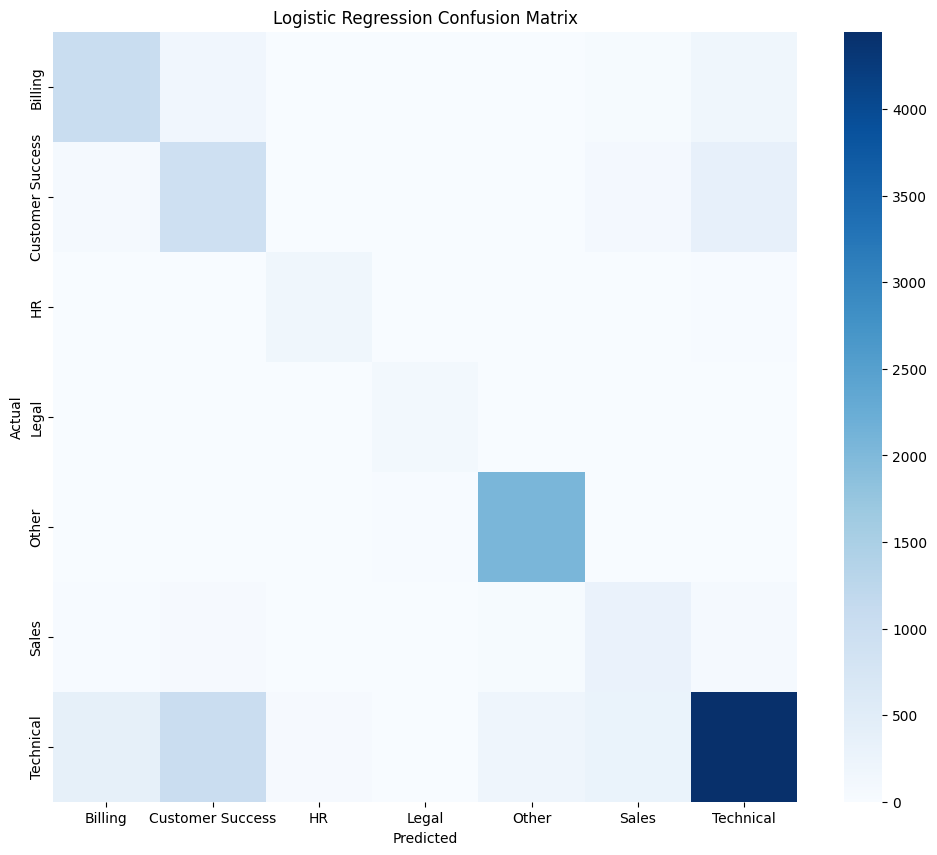

In [307]:
# Confusion Matrix Visualization
lr_cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(12, 10))
sns.heatmap(
    lr_cm,
    cmap="Blues",
    xticklabels=le.classes_,
    yticklabels=le.classes_
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Logistic Regression Confusion Matrix")
plt.show()

In [308]:
text = """Help needed: Docker container failing to run on local system

Hello,

I'm having trouble running a Docker container on my local machine and need assistance.

Details:

Problem: Container fails to start (exits immediately / shows error) when I run the image.

Environment: Local workstation in Chennai (Workspace JST), OS: [insert OS and version], Docker version: [insert Docker version].

Command used: docker run [insert full command you used]

Error message / behavior: [paste the exact error output or describe what happens]

Steps I've tried: restarted Docker, rebooted machine, pulled the image again, checked container logs (no resolution).

Could you please help diagnose and resolve this? Let me know if you need any additional logs or system information — I can provide docker logs, docker inspect output, and system info on request."""

text_cleaned = text_preprocessing(text)
X_new = vectorizer.transform([text_cleaned])
prediction = lr_model.predict(X_new)
predicted_label = le.inverse_transform(prediction)
predicted_label

array(['Technical'], dtype=object)